# Testing CIFAR-100 Image Classification with a CNN from Scratch and Tunning Hyperparameters to See the Impact in Accuracy for Each Hyperparameter. 

**Name:** Shaktiman Choudhury (ID: 2512876)

## Aim of the exercise
Train a convolutional neural network from scratch on a reduced subset of CIFAR-100 and study how different parameters (dense size/depth, number and shape of convolution blocks, activation function, optimizer and learning rate, batch size, and number of epochs) affect classification accuracy.
In my case, I have access to my personal PC and decent CPU/GPU pair which is somewhat capable to train CNN models. However, it would take me a a great amount of time to train the model so many times and do experiments with the entire dataset. So, I use 12 classes and cap the number of images per class so experiments can be run quickly.
I split the training subset into a training and a validation part. Model settings are compared on the validation set, and each configuration is finally evaluated once on the held-out test set. This avoids tuning directly on the test data, which would give an over-optimistic accuracy.
Each experiment changes one setting at a time, starting from a fixed baseline, so the difference in accuracy can be attributed to that single change. The goal is to report on how changes the training parameters impact the performance of the model. 

## Task 1

Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import datasets, layers, models, optimizers
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [ ]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

**Data loading**

In [3]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = datasets.cifar100.load_data(label_mode="fine")
y_train_full = y_train_full.flatten()
y_test_full  = y_test_full.flatten()

print("Full train:", x_train_full.shape, y_train_full.shape)
print("Full test :", x_test_full.shape, y_test_full.shape)
print("Number of classes:", len(np.unique(y_train_full)))

Full train: (50000, 32, 32, 3) (50000,)
Full test : (10000, 32, 32, 3) (10000,)
Number of classes: 100


Data summary

In [4]:
print("First 10 train labels:", y_train_full[:10])
print("Pixel value range     :", x_train_full.min(), "to", x_train_full.max())
print("Images per class (train):", np.bincount(y_train_full)[:12], "...")

First 10 train labels: [19 29  0 11  1 86 90 28 23 31]
Pixel value range     : 0 to 255
Images per class (train): [500 500 500 500 500 500 500 500 500 500 500 500] ...


## Class selection and data preprocessing
To keep the experiments manageable I select 12 classes. for the data preprocessing, I will cap the number of images per class, normalise pixels to [0, 1], remap the labels to 0 to 11 range, and splt a validation split out of the training subset. I maDE a function so that I can use it for both task 5 and 6.

In [5]:
def make_subset(selected_classes, max_train_per_class=500, max_test_per_class=100, val_size=0.2, img_size=32, seed=SEED):
    rng = np.random.RandomState(seed)

    def filter_cap(x, y, cap):
        xs, ys = [], []
        for cls in selected_classes:
            idx = np.where(y == cls)[0]
            idx = rng.permutation(idx)[:cap]      
            xs.append(x[idx]); ys.append(y[idx])
        return np.concatenate(xs), np.concatenate(ys)

    x_tr, y_tr = filter_cap(x_train_full, y_train_full, max_train_per_class)
    x_te, y_te = filter_cap(x_test_full,  y_test_full,  max_test_per_class)

    remap = {old: new for new, old in enumerate(selected_classes)}
    y_tr = np.array([remap[v] for v in y_tr])
    y_te = np.array([remap[v] for v in y_te])

    x_tr = x_tr.astype("float32") / 255.0
    x_te = x_te.astype("float32") / 255.0

    if img_size != 32:
        x_tr = tf.image.resize(x_tr, (img_size, img_size)).numpy()
        x_te = tf.image.resize(x_te, (img_size, img_size)).numpy()

    x_tr, x_val, y_tr, y_val = train_test_split(
        x_tr, y_tr, test_size=val_size, random_state=seed, stratify=y_tr)

    n = len(selected_classes)
    return {
        "x_train": x_tr, "y_train": y_tr, "y_train_cat": to_categorical(y_tr, n),
        "x_val":   x_val, "y_val": y_val, "y_val_cat":  to_categorical(y_val, n),
        "x_test":  x_te, "y_test": y_te, "y_test_cat":  to_categorical(y_te, n),
        "num_classes": n, "classes": selected_classes,
    }

# Subset 1: the first 12 classes.
SUBSET1_CLASSES = list(range(12))
ds1 = make_subset(SUBSET1_CLASSES)
print("Subset 1 — train:", ds1["x_train"].shape,
      "val:", ds1["x_val"].shape, "test:", ds1["x_test"].shape)

Subset 1 — train: (4800, 32, 32, 3) val: (1200, 32, 32, 3) test: (1200, 32, 32, 3)


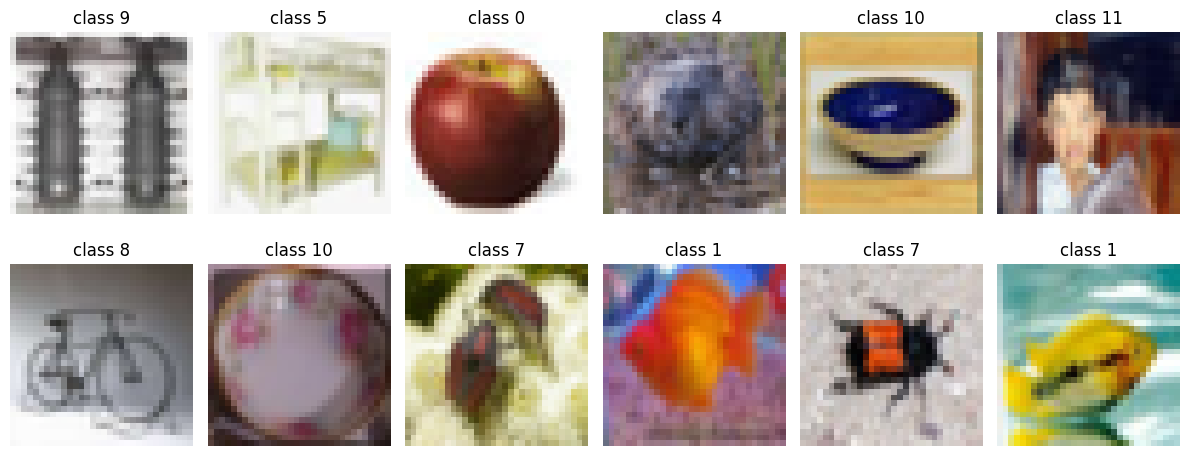

In [6]:
plt.figure(figsize=(12, 5))
for i in range(12):
    plt.subplot(2, 6, i + 1)
    plt.imshow(ds1["x_train"][i])
    plt.title(f'class {ds1["y_train"][i]}')
    plt.axis("off")
plt.tight_layout()
plt.show()

## Task 2
I made the baseline  CNN with three convolution + max-pooling blocks (32 -> 64 -> 128 filters, 3x3 kernels) as the feature extractor, then one dense layer (256 units) with dropout, and a softmax output. It is trained with Adam (lr = 1e-3), batch size 64, for 20 epochs. I made this into a function so that I can change the params later to experiment and see the changes in accuracy.

In [7]:
def build_cnn(input_shape, num_classes,conv_filters=(32, 64, 128), kernel_size=(3, 3),dense_units=(256,), activation="relu",optimizer_name="adam", learning_rate=1e-3, dropout_rate=0.3):
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    for f in conv_filters:
        model.add(layers.Conv2D(f, kernel_size, padding="same", activation=activation))
        model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Flatten())
    for u in dense_units:
        model.add(layers.Dense(u, activation=activation))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(num_classes, activation="softmax"))

    name = optimizer_name.lower()
    if   name == "adam":    opt = optimizers.Adam(learning_rate=learning_rate)
    elif name == "sgd":     opt = optimizers.SGD(learning_rate=learning_rate)
    elif name == "rmsprop": opt = optimizers.RMSprop(learning_rate=learning_rate)
    elif name == "adamw":   opt = optimizers.AdamW(learning_rate=learning_rate)
    
    model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])
    return model


I will write a function to plot the train vs val accuracy graph.

In [8]:
def plot_history(history, title="Training history"):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="val")
    plt.title(f"{title} - loss"); plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="val")
    plt.title(f"{title} - accuracy"); plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend()
    plt.tight_layout(); plt.show()

## Task 3

In [9]:
DEFAULTS = dict(conv_filters=(32, 64, 128), kernel_size=(3, 3), dense_units=(256,),
                activation="relu", optimizer_name="adam", learning_rate=1e-3,
                dropout_rate=0.3, batch_size=64, epochs=20)

def run_experiment(name, ds, **overrides):
    cfg = {**DEFAULTS, **overrides}
    model = build_cnn(ds["x_train"].shape[1:], ds["num_classes"], conv_filters=cfg["conv_filters"], kernel_size=cfg["kernel_size"], dense_units=cfg["dense_units"], activation=cfg["activation"], optimizer_name=cfg["optimizer_name"], learning_rate=cfg["learning_rate"], dropout_rate=cfg["dropout_rate"])
    history = model.fit(ds["x_train"], ds["y_train_cat"], validation_data=(ds["x_val"], ds["y_val_cat"]), epochs=cfg["epochs"], batch_size=cfg["batch_size"], verbose=0)
    _, test_acc = model.evaluate(ds["x_test"], ds["y_test_cat"], verbose=0)
    row = {"experiment": name,
           "conv_filters": str(cfg["conv_filters"]), "kernel": str(cfg["kernel_size"]),
           "dense_units": str(cfg["dense_units"]), "activation": cfg["activation"],
           "optimizer": cfg["optimizer_name"], "lr": cfg["learning_rate"],
           "batch": cfg["batch_size"], "epochs": cfg["epochs"],
           "train_acc": round(max(history.history["accuracy"]), 4),
           "val_acc":   round(max(history.history["val_accuracy"]), 4),
           "test_acc":  round(float(test_acc), 4)}
    return model, history, row

## Task 4

Testing the Trained model using test set to see the accuracy. 

{'experiment': 'baseline', 'conv_filters': '(32, 64, 128)', 'kernel': '(3, 3)', 'dense_units': '(256,)', 'activation': 'relu', 'optimizer': 'adam', 'lr': 0.001, 'batch': 64, 'epochs': 20, 'train_acc': 0.8963, 'val_acc': 0.63, 'test_acc': 0.6225}


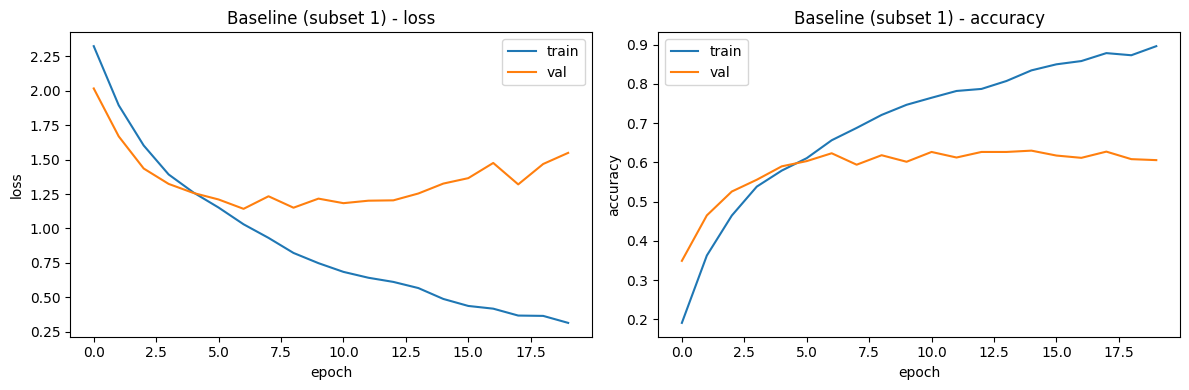

In [10]:
baseline_model, baseline_history, baseline_row = run_experiment("baseline", ds1)
print(baseline_row)
plot_history(baseline_history, "Baseline (subset 1)")

The baseline model trains smoothly: validation accuracy rises in the first few epochs and then flattens, while training accuracy keeps climbing. The widening gap between them shows that the model starts to overfit in the later epochs, which is the main constraint the experiments below run up against. From a optimization perspective, an automated hyperparameter search (like a Grid SearchCV) could be used to sweep for the parameters that balance high validation accuracy with the lowest validation loss. However, an automated sweep alone does not solve the underlying overfitting problem without adding regularization, and usinf grid search  is outside the purpose of this exercise.

## Task 5 Hyperparameter Tuning experiments
Each row below changes one setting relative to the baseline cnn model that I trained in task 3. The class subset and the train/val split are held fixed so the comparison is fair.
- dense layer size and depth — larger_dens, deeper_dense
- number / shape of convolution blocks — fewer_conv,more_conv, larger_kernel_5x5
- activation function —sigmoid_activation, tanh_activation
- activation combined with depth — sigmoid_deeper 
- optimizer and learning rate — sgd_optimizer, rmsprop_optimizer, adam_high_lr, adam_low_lr
- batch size — smaller_batch, larger_batch
- epochs — more_epochs

In [11]:
experiments = [
    ("baseline",          {}),
    # dense size / depth
    ("larger_dense",      dict(dense_units=(512,))),
    ("deeper_dense",      dict(dense_units=(256, 128))),
    # conv blocks / shape
    ("fewer_conv",        dict(conv_filters=(32, 64))),
    ("more_conv",         dict(conv_filters=(32, 64, 128, 256))),
    ("larger_kernel_5x5", dict(kernel_size=(5, 5))),
    # activation
    ("sigmoid_activation", dict(activation="sigmoid")),
    ("tanh_activation",    dict(activation="tanh")),
    # activation + depth combination
    ("sigmoid_deeper",     dict(activation="sigmoid", conv_filters=(32, 64, 128, 256))),
    # optimizer / learning rate
    ("sgd_optimizer",      dict(optimizer_name="sgd", learning_rate=1e-2)),
    ("rmsprop_optimizer",  dict(optimizer_name="rmsprop")),
    ("adam_high_lr",       dict(learning_rate=1e-2)),
    ("adam_low_lr",        dict(learning_rate=1e-4)),
    # batch size / epochs
    ("smaller_batch",      dict(batch_size=32)),
    ("larger_batch",       dict(batch_size=128)),
    ("more_epochs",        dict(epochs=40)),
]

In [12]:
rows, histories = [], {}
for name, overrides in experiments:
    print("running:", name)
    _, hist, row = run_experiment(name, ds1, **overrides)
    rows.append(row); histories[name] = hist

results_df = pd.DataFrame(rows).sort_values("val_acc", ascending=False).reset_index(drop=True)
results_df.to_csv("cifar100_experiments_subset1.csv", index=False)
results_df

running: baseline
running: larger_dense
running: deeper_dense
running: fewer_conv
running: more_conv
running: larger_kernel_5x5
running: sigmoid_activation
running: tanh_activation
running: sigmoid_deeper
running: sgd_optimizer
running: rmsprop_optimizer
running: adam_high_lr
running: adam_low_lr
running: smaller_batch
running: larger_batch
running: more_epochs


,experiment,conv_filters,kernel,dense_units,activation,optimizer,lr,batch,epochs,train_acc,val_acc,test_acc
0,tanh_activation,"(32, 64, 128)","(3, 3)","(256,)",tanh,adam,0.0010,64,20,0.9998,0.6500,0.6492
1,larger_batch,"(32, 64, 128)","(3, 3)","(256,)",relu,adam,0.0010,128,20,0.8573,0.6458,0.6283
2,more_epochs,"(32, 64, 128)","(3, 3)","(256,)",relu,adam,0.0010,64,40,0.9867,0.6450,0.6250
3,fewer_conv,"(32, 64)","(3, 3)","(256,)",relu,adam,0.0010,64,20,0.9254,0.6450,0.6175
4,deeper_dense,"(32, 64, 128)","(3, 3)","(256, 128)",relu,adam,0.0010,64,20,0.8783,0.6442,0.6367
5,larger_dense,"(32, 64, 128)","(3, 3)","(512,)",relu,adam,0.0010,64,20,0.9477,0.6425,0.6042
6,baseline,"(32, 64, 128)","(3, 3)","(256,)",relu,adam,0.0010,64,20,0.9215,0.6342,0.6367
7,smaller_batch,"(32, 64, 128)","(3, 3)","(256,)",relu,adam,0.0010,32,20,0.9442,0.6342,0.6233
8,rmsprop_optimizer,"(32, 64, 128)","(3, 3)","(256,)",relu,rmsprop,0.0010,64,20,0.9323,0.6308,0.6258
9,more_conv,"(32, 64, 128, 256)","(3, 3)","(256,)",relu,adam,0.0010,64,20,0.9592,0.6225,0.6200


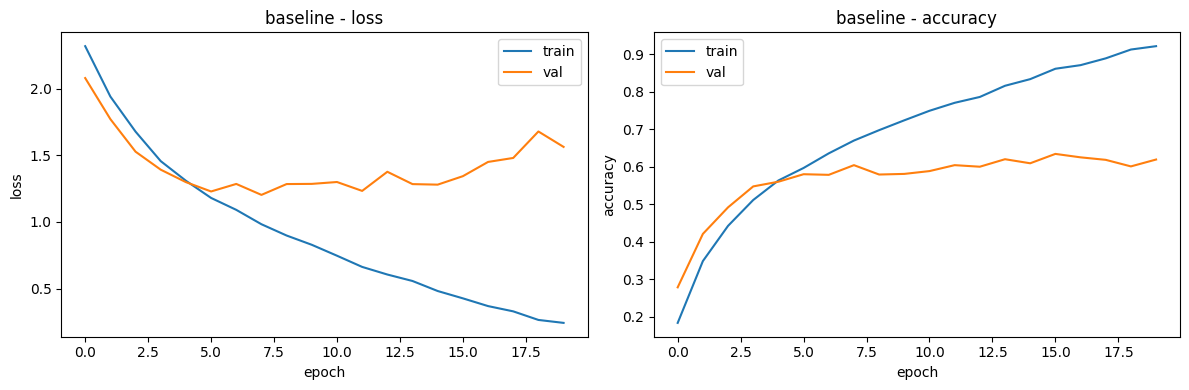

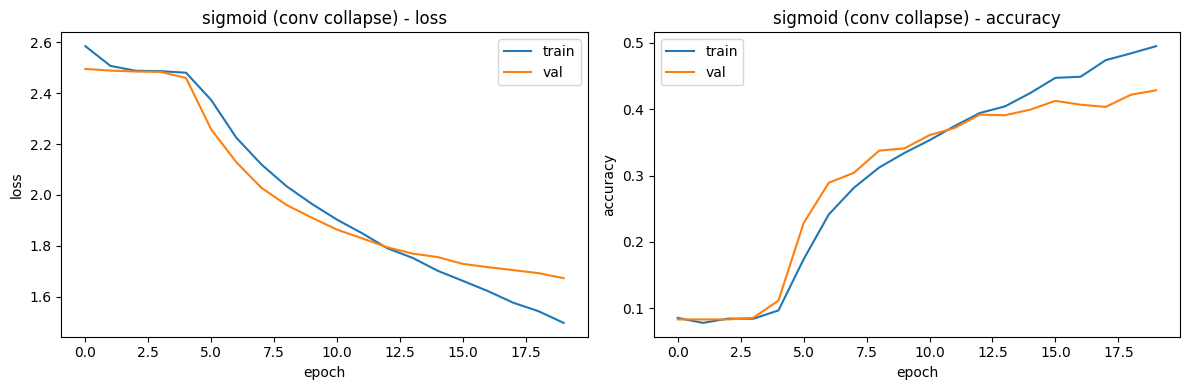

In [13]:
plot_history(histories["baseline"], "baseline")
plot_history(histories["sigmoid_activation"], "sigmoid (conv collapse)")

## 7. Confusion matrix of the best validation model
To look beyond a single accuracy number, the confusion matrix below is computed for the configuration with the highest **validation** accuracy. It shows which of the 12 classes are confused most often.

Best-validation configuration: tanh_activation


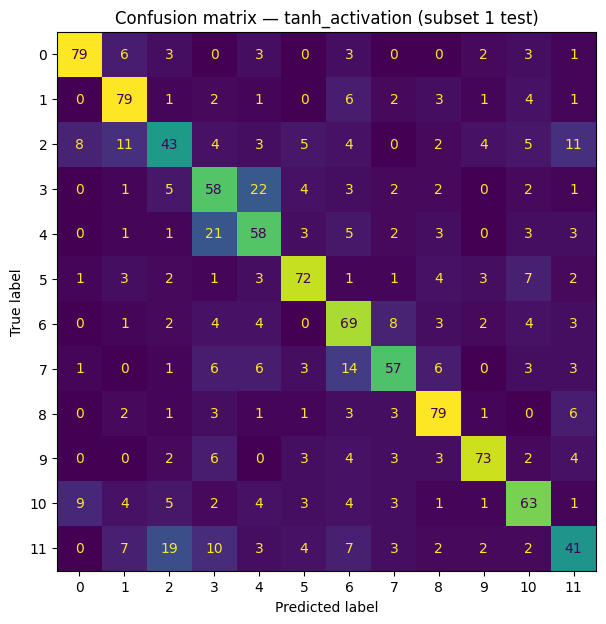

In [14]:
best_name = results_df.iloc[0]["experiment"]
best_overrides = dict(experiments)[best_name]
print("Best-validation configuration:", best_name)

best_model, _, _ = run_experiment(best_name, ds1, **best_overrides)
y_pred = best_model.predict(ds1["x_test"], verbose=0).argmax(axis=1)

cm = confusion_matrix(ds1["y_test"], y_pred)
fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False)
ax.set_title(f"Confusion matrix — {best_name} (subset 1 test)")
plt.show()

## Task 6:  Repeating the hyperparameter tuning for another subset of CIFAR 100 and training a new model and comparing with the baseline
I am using a smaller number of samples per class so I am hoping that this time training will take less time. I reran a representative set of configurations covering each comparison group. The aim is to check whether the the changes in perfomance from task 5 hold on different classes. These experiments on Subset 2 focuses on the experiments that produced the most meaningful accuracy differences in subset 1.

In [15]:
SUBSET2_CLASSES = list(range(12, 24))
ds2 = make_subset(SUBSET2_CLASSES, max_train_per_class=300) 
print("Subset 2 — train:", ds2["x_train"].shape,
      "val:", ds2["x_val"].shape, "test:", ds2["x_test"].shape)

repeat = [
    ("baseline",           {}),
    ("fewer_conv",         dict(conv_filters=(32, 64))),
    ("larger_kernel_5x5",  dict(kernel_size=(5, 5))),
    ("sigmoid_activation", dict(activation="sigmoid")),
    ("tanh_activation",    dict(activation="tanh")),
    ("sgd_optimizer",      dict(optimizer_name="sgd", learning_rate=1e-2)),
    ("rmsprop_optimizer",  dict(optimizer_name="rmsprop")),
    ("adam_high_lr",       dict(learning_rate=1e-2)),
    ("adam_low_lr",        dict(learning_rate=1e-4)),
    ("smaller_batch",      dict(batch_size=32)),
    ("more_epochs",        dict(epochs=40)),
]

rows2 = []
for name, overrides in repeat:
    print("running (subset 2):", name)
    _, _, row = run_experiment(name, ds2, **overrides)
    rows2.append(row)

results_df2 = pd.DataFrame(rows2).sort_values("val_acc", ascending=False).reset_index(drop=True)
results_df2.to_csv("cifar100_experiments_subset2.csv", index=False)
results_df2

Subset 2 — train: (2880, 32, 32, 3) val: (720, 32, 32, 3) test: (1200, 32, 32, 3)
running (subset 2): baseline
running (subset 2): fewer_conv
running (subset 2): larger_kernel_5x5
running (subset 2): sigmoid_activation
running (subset 2): tanh_activation
running (subset 2): sgd_optimizer
running (subset 2): rmsprop_optimizer
running (subset 2): adam_high_lr
running (subset 2): adam_low_lr
running (subset 2): smaller_batch
running (subset 2): more_epochs


,experiment,conv_filters,kernel,dense_units,activation,optimizer,lr,batch,epochs,train_acc,val_acc,test_acc
0,more_epochs,"(32, 64, 128)","(3, 3)","(256,)",relu,adam,0.0010,64,40,0.9861,0.6625,0.6358
1,smaller_batch,"(32, 64, 128)","(3, 3)","(256,)",relu,adam,0.0010,32,20,0.9517,0.6514,0.6475
2,tanh_activation,"(32, 64, 128)","(3, 3)","(256,)",tanh,adam,0.0010,64,20,0.9937,0.6486,0.6425
3,baseline,"(32, 64, 128)","(3, 3)","(256,)",relu,adam,0.0010,64,20,0.8938,0.6306,0.6025
4,fewer_conv,"(32, 64)","(3, 3)","(256,)",relu,adam,0.0010,64,20,0.9330,0.6250,0.6308
5,rmsprop_optimizer,"(32, 64, 128)","(3, 3)","(256,)",relu,rmsprop,0.0010,64,20,0.9080,0.6222,0.6092
6,larger_kernel_5x5,"(32, 64, 128)","(5, 5)","(256,)",relu,adam,0.0010,64,20,0.9431,0.5889,0.6108
7,adam_low_lr,"(32, 64, 128)","(3, 3)","(256,)",relu,adam,0.0001,64,20,0.5882,0.5250,0.5417
8,adam_high_lr,"(32, 64, 128)","(3, 3)","(256,)",relu,adam,0.0100,64,20,0.6747,0.4514,0.4558
9,sigmoid_activation,"(32, 64, 128)","(3, 3)","(256,)",sigmoid,adam,0.0010,64,20,0.4212,0.4056,0.4108


## Task 7: Report

### Methodology

For all the experiments I kept a one-variable-at-a-time approach where I only change one hyperparameter per run and keep everything else the same as the baseline. I also set a fixed random seed so the data splits are identical across runs, which means any change in accuracy can be attributed to the hyperparameter I changed and not to randomness in the data. I split the training data into a training and validation part (80/20) so that I am not tuning directly on the test set, which would give an over-optimistic accuracy. The test set is only used once at the end of each experiment for the final evaluation.

### Interpretation of the comparison table for the first subset of CIFAR 100
In general, it seems the model is overfitting where the training set accuracy is often more than 92% to 99% while the test accuracy is in the 60–65% range. Somehow increasing the batch size helps with the overfitting, where the training accuracy is kept at 85.73% while the test performance (62.83%) remains close to the baseline. Shrinking the batch size to 32 leads to a test accuracy of 62.33%. Modifying the convolutional structure shifts performance slightly: adding a 4th convolutional block results in a test accuracy of 62.00%, while using 5x5 kernels drops it to 59.83%. 

The clear structural failure modes are highly reproducible. Surprisingly, the sigmoid activation function drops the accuracy from the baseline down to 42.92%, while making the network deeper with a sigmoid activation causes a total learning collapse to random chance (8.33%). Plain SGD achieves only 36.92%, and a high learning rate (adam_high_lr, alpha = 0.01) drops performance to 39.33%. Among alternative activation functions, tanh achieved a very high training accuracy (99.98%) and a top test performance of 64.92%, clustering tightly with the baseline ReLU (63.67%). The individual experiments show that the pipeline benefits from alternative smooth activations and balanced updates. To systematically combat the persistent overfitting observed across these configurations, future work should focus on training with all of the training data for that class rather than capping the number of samples like I did.

### Interpretation of the comparision table for the second subset of CIFAR 100
Absolute accuracy is a little lower than on subset 1 (due to fewer images per class and different, harder classes), but accuracy improvements or degradation trends are similar across all tests. Sigmoid in the conv layers and a high 1e-2 learning rate cause severe performance degradation, dropping accuracy to 41.08% and 45.58% respectively, while plain SGD remains weak at 40.67%. In this run, the larger 5x5 kernel performed at 61.08%. 

Importantly, reducing the architecture to fewer convolutional blocks (2 blocks) still clearly outperformed the 3-block baseline, reaching 63.08% compared to the baseline's 60.25%. Training for 40 epochs (63.58%) or narrowing the batch size to 32 (64.75%) yielded strong test numbers but high training parameters. This confirms that the primary conclusions—especially regarding major optimization and activation drops—are driven by properties of the method and data scale rather than a specific class selection. The main difference was that fewer conv blocks hurt on subset 1 but outperformed the baseline on subset 2, likely because with fewer images per class the simpler model had less room to overfit. Overall, the fact that the same high-level parameters and boundaries carry over across two different class selections gives me more confidence that these are real effects and not just artifacts of one particular set of classes.

### Experiment Summary

- The **baseline** already classifies the 12-class subset reasonably well, so the experiments are about understanding *which* changes matter, not rescuing a weak model.
- **Dense size/depth** gave the weakest, mostly noise-level changes the bottleneck is feature extraction, not the classifier head.
- **Convolution structure** mattered more, but the baseline depth was already about right;fewer blocks underfit on the first subset but preserved critical structural resolution on the second subset; more blocks and larger kernels consistently degraded performance.
- **Activation** produced the clearest result: ReLU/tanh work, sigmoid in the conv layers fails (vanishing gradients), and stays failed when the network is made deeper.
- **Optimizer/learning rate** was the most sensitive area: lr = 1e-2 causes sharp accuracy drop, lr = 1e-4 underfits, adaptive optimizers at 1e-3 work well, and plain SGD lags.
- **Batch size / epochs** had the most impact on accuracy and performance. a smaller batch generalised slightly worse, while more epochs had the best accuracy but the model was severly overfitting.
- The effects were **stable across both subsets**, which is the strongest evidence that they are real and not artifacts of one class selection.

The single biggest limiter throughout was overfitting (train accuracy well above validation/test). The most promising next steps, all outside this exercise, would be data augmentation, batch normalisation, and early stopping.

### Conclusions
Not all hyperparameters mattered equally. The highest differnce makers are: avoid saturating activations in the conv layers (sigmoid fails badly), keep the learning rate moderate (1e-3) with an adaptive optimizer, and balanced conv blocks for the input size. Dense width/depth, the exact adaptive optimizer, and small batch/epoch tweaks made only noise-level differences. The recurring limiter was overfitting (training accuracy well above validation/test)
In future I plan to do some other test outside of this exercise to improve the performance of this task. Some of which that comes to mind: 

- Data augmentation (random flips, crops, small rotations)
- Batch normalisation after conv layers
- Early stopping / learning-rate scheduling 
- More images per class if the runtime budget allows.
